In [ ]:
!pip install iterative-stratification tensorflow -q

import pandas as pd, numpy as np, pickle, ast
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              hamming_loss, jaccard_score, classification_report)
from scipy.special import expit

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
sns.set(style='whitegrid'); plt.rcParams['figure.dpi'] = 110
import warnings; warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/skripsi_avoskin'

df = pd.read_csv(f'{SAVE_DIR}/df_clean.csv')
df['accept'] = df['accept'].apply(ast.literal_eval)

with open(f'{SAVE_DIR}/classes.pkl', 'rb') as f:
    classes = pickle.load(f)
with open(f'{SAVE_DIR}/fold_splits.pkl', 'rb') as f:
    fold_splits = pickle.load(f)

mlb = MultiLabelBinarizer(classes=classes)
texts = df["clean_text"].values
Y = mlb.fit_transform(df["accept"])

print(f"Data: {len(df)} baris, {len(classes)} label, {len(fold_splits)} fold")

Mounted at /content/drive
Data: 4226 baris, 12 label, 5 fold


In [ ]:
def evaluate_full(name, Yt, Yp, classes):
    agg = {
        'F1_micro'        : f1_score(Yt, Yp, average='micro', zero_division=0),
        'F1_macro'        : f1_score(Yt, Yp, average='macro', zero_division=0),
        'Precision_micro' : precision_score(Yt, Yp, average='micro', zero_division=0),
        'Precision_macro' : precision_score(Yt, Yp, average='macro', zero_division=0),
        'Recall_micro'    : recall_score(Yt, Yp, average='micro', zero_division=0),
        'Recall_macro'    : recall_score(Yt, Yp, average='macro', zero_division=0),
        'Hamming Loss'    : hamming_loss(Yt, Yp),
        'Jaccard (samples)': jaccard_score(Yt, Yp, average='samples', zero_division=0),
    }
    per_label = pd.DataFrame(
        classification_report(Yt, Yp, target_names=classes, output_dict=True, zero_division=0)
    ).T.loc[classes]
    return agg, per_label

def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return np.asarray(model.predict_proba(X))
    elif hasattr(model, "decision_function"):
        return expit(model.decision_function(X))
    raise ValueError("Model tidak punya predict_proba/decision_function")

def tune_threshold(model, Xval, Yval, grid=np.arange(0.1, 0.9, 0.05)):
    scores_val = get_scores(model, Xval)
    best_thr, best_f1 = 0.5, -1
    for thr in grid:
        f1 = f1_score(Yval, (scores_val > thr).astype(int), average='micro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr, best_f1

def tune_threshold_per_label(model, Xval, Yval, grid=np.arange(0.1, 0.9, 0.05)):
    scores_val = get_scores(model, Xval)
    thr_list = []
    for j in range(Yval.shape[1]):
        best_thr, best_f1 = 0.5, -1
        for thr in grid:
            f1 = f1_score(Yval[:, j], (scores_val[:, j] > thr).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_thr = f1, thr
        thr_list.append(best_thr)
    return np.array(thr_list)

def evaluate_threshold_variants(
    model, X_test, Y_test, X_val, Y_val,
    model_name, scenario, fold,
    all_agg, all_perlabel, all_thr, all_cm,
    final_preds, classes):
    """Menjalankan & mencatat 3 varian threshold (default/global/per-label) untuk 1 model di 1 fold."""
    thr_g, _   = tune_threshold(model, X_val, Y_val)
    thr_pl     = tune_threshold_per_label(model, X_val, Y_val)
    scores_test = get_scores(model, X_test)

    variants = {
        'threshold_default_0.5': (scores_test > 0.5).astype(int),
        'threshold_global'      : (scores_test > thr_g).astype(int),
        'threshold_per_label'   : (scores_test > thr_pl).astype(int),
    }

    for thr_mode, pred in variants.items():
        final_preds[f"{model_name}_{thr_mode}"] = (Y_test.copy(), pred.copy())
        agg, per_label = evaluate_full(f"{model_name}-{thr_mode}", Y_test, pred, classes)
        agg.update({'fold': fold, 'model': model_name, 'scenario': scenario, 'threshold_mode': thr_mode})
        all_agg.append(agg)

        per_label = per_label.reset_index().rename(columns={'index': 'label'})
        per_label['fold'] = fold; per_label['model'] = model_name
        per_label['scenario'] = scenario; per_label['threshold_mode'] = thr_mode
        all_perlabel.append(per_label)

        print(f"  {model_name:12s} | {thr_mode:20s} -> F1_micro={agg['F1_micro']:.4f}  F1_macro={agg['F1_macro']:.4f}")

    all_thr.append({'fold': fold, 'model': model_name, 'scenario': scenario,
                     'threshold_global': thr_g, 'threshold_per_label': list(thr_pl)})

In [ ]:
MAX_WORDS = 8000
MAX_LEN = 60

def build_models_tfidf():
    return {
        'Naive Bayes': OneVsRestClassifier(ComplementNB(alpha=0.5)),
        'SVM'        : OneVsRestClassifier(LinearSVC(C=1.0, max_iter=5000)),
    }

class LSTMWrapper:
    def __init__(self, keras_model):
        self.model = keras_model
    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)

def build_lstm(n_labels, vocab_size):
    model = Sequential([
        Embedding(vocab_size, 128, input_length=MAX_LEN),
        (LSTM(64)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_labels, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

In [ ]:
SKENARIO = 'murni'
all_agg, all_perlabel, all_thr, all_cm = [], [], [], []
final_preds = {}

for fold, (tr_full_idx, te_idx) in enumerate(fold_splits, start=1):
    print(f"\n{'='*25} FOLD {fold}/5 - {SKENARIO} {'='*25}")

    X_train_full_t, X_test_t = texts[tr_full_idx], texts[te_idx]
    Y_train_full, Y_test = Y[tr_full_idx], Y[te_idx]

    # --- Split train_full -> train-inti & validation, STRATIFIED ---
    msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.125, random_state=42)
    tr_idx, val_idx = next(msss.split(X_train_full_t, Y_train_full))
    X_train_t, X_val_t = X_train_full_t[tr_idx], X_train_full_t[val_idx]
    Y_train, Y_val = Y_train_full[tr_idx], Y_train_full[val_idx]

    # --- TF-IDF: fit HANYA di train-inti ---
    tfidf = TfidfVectorizer(min_df=2, max_df=0.95, ngram_range=(1,2), sublinear_tf=True)
    X_train = tfidf.fit_transform(X_train_t)
    X_val   = tfidf.transform(X_val_t)
    X_test  = tfidf.transform(X_test_t)

    # --- Model NB, SVM ---
    for name, model in build_models_tfidf().items():
        model.fit(X_train, Y_train)
        evaluate_threshold_variants(model, X_test, Y_test, X_val, Y_val, name, SKENARIO, fold,
                                     all_agg, all_perlabel, all_thr, all_cm, final_preds, classes)

    # --- Tokenizer & padding KHUSUS LSTM, fit HANYA di train-inti ---
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train_t)

    X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_t), maxlen=MAX_LEN)
    X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val_t),   maxlen=MAX_LEN)
    X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test_t),  maxlen=MAX_LEN)

    vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
    lstm_keras = build_lstm(n_labels=len(classes), vocab_size=vocab_size)
    history = lstm_keras.fit(X_train_seq, Y_train, epochs=15, batch_size=32,
                   validation_data=(X_val_seq, Y_val),
                   callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
                   verbose=0)

    lstm_model = LSTMWrapper(lstm_keras)
    evaluate_threshold_variants(lstm_model, X_test_seq, Y_test, X_val_seq, Y_val, 'LSTM', SKENARIO, fold,
                                 all_agg, all_perlabel, all_thr, all_cm, final_preds, classes)

    print(f"Fold {fold} selesai untuk semua model (NB, SVM, LSTM).")

df_agg_baseline = pd.DataFrame(all_agg)
df_perlabel_baseline = pd.concat(all_perlabel, ignore_index=True)
df_thr_baseline = pd.DataFrame(all_thr)

print("\nSemua fold selesai.")


========================= FOLD 1/5 - murni =========================
  Naive Bayes  | threshold_default_0.5 -> F1_micro=0.7959  F1_macro=0.3846
  Naive Bayes  | threshold_global     -> F1_micro=0.7959  F1_macro=0.3846
  Naive Bayes  | threshold_per_label  -> F1_micro=0.7223  F1_macro=0.3918
  SVM          | threshold_default_0.5 -> F1_micro=0.8453  F1_macro=0.5196
  SVM          | threshold_global     -> F1_micro=0.8453  F1_macro=0.5196
  SVM          | threshold_per_label  -> F1_micro=0.8399  F1_macro=0.6145
  LSTM         | threshold_default_0.5 -> F1_micro=0.8255  F1_macro=0.3420
  LSTM         | threshold_global     -> F1_micro=0.8248  F1_macro=0.3574
  LSTM         | threshold_per_label  -> F1_micro=0.7938  F1_macro=0.4622
Fold 1 selesai untuk semua model (NB, SVM, LSTM).

========================= FOLD 2/5 - murni =========================
  Naive Bayes  | threshold_default_0.5 -> F1_micro=0.7889  F1_macro=0.3478
  Naive Bayes  | threshold_global     -> F1_micro=0.7889  F1_macro

In [ ]:
ringkasan_murni = (df_agg_baseline
    .groupby(['model', 'threshold_mode'])[['F1_micro','F1_macro','Precision_macro','Recall_macro', 'Hamming Loss','Jaccard (samples)']]
    .agg(['mean','std']).round(4))
display(ringkasan_murni)

F1_micro         F1_macro          \
                                      mean     std     mean     std   
model       threshold_mode                                            
LSTM        threshold_default_0.5   0.8044  0.0120   0.3149  0.0168   
            threshold_global        0.8068  0.0101   0.3275  0.0178   
            threshold_per_label     0.7827  0.0098   0.4089  0.0328   
Naive Bayes threshold_default_0.5   0.7957  0.0086   0.3573  0.0173   
            threshold_global        0.7953  0.0079   0.3610  0.0198   
            threshold_per_label     0.7339  0.0175   0.3853  0.0124   
SVM         threshold_default_0.5   0.8471  0.0056   0.4721  0.0274   
            threshold_global        0.8472  0.0051   0.5250  0.0171   
            threshold_per_label     0.8394  0.0046   0.6032  0.0128   

                                  Precision_macro         Recall_macro  \
                                             mean     std         mean   
model       threshold_mode                                               
LSTM        threshold_default_0.5          0.3578  0.0433       0.3042   
            threshold_global               0.3610  0.0403       0.3265   
            threshold_per_label            0.4033  0.0351       0.4456   
Naive Bayes threshold_default_0.5          0.4646  0.0517       0.3389   
            threshold_global               0.4604  0.0452       0.3445   
            threshold_per_label            0.4060  0.0425       0.4459   
SVM         threshold_default_0.5          0.7390  0.1056       0.4141   
            threshold_global               0.7772  0.0901       0.4749   
            threshold_per_label            0.6371  0.0169       0.6097   

                                          Hamming Loss          \
                                      std         mean     std   
model       threshold_mode                                       
LSTM        threshold_default_0.5  0.0151       0.0686  0.0046   
            threshold_global       0.0196       0.0696  0.0038   
            threshold_per_label    0.0332       0.0838  0.0054   
Naive Bayes threshold_default_0.5  0.0107       0.0734  0.0030   
            threshold_global       0.0183       0.0741  0.0016   
            threshold_per_label    0.0372       0.1089  0.0121   
SVM         threshold_default_0.5  0.0176       0.0539  0.0016   
            threshold_global       0.0189       0.0565  0.0020   
            threshold_per_label    0.0272       0.0604  0.0021   

                                  Jaccard (samples)          
                                               mean     std  
model       threshold_mode                                   
LSTM        threshold_default_0.5            0.7251  0.0154  
            threshold_global                 0.7297  0.0147  
            threshold_per_label              0.7197  0.0098  
Naive Bayes threshold_default_0.5            0.7178  0.0094  
            threshold_global                 0.7179  0.0096  
            threshold_per_label              0.6683  0.0192  
SVM         threshold_default_0.5            0.7789  0.0072  
            threshold_global                 0.7766  0.0065  
            threshold_per_label              0.7686  0.0059

In [ ]:
ringkasan_f1_perlabel_murni = (
    df_perlabel_baseline[df_perlabel_baseline['threshold_mode'] == 'threshold_per_label']
    .groupby(['model','label'])['f1-score']
    .agg(['mean','std'])
    .round(4)
    .reset_index()
)

display(ringkasan_f1_perlabel_murni)

,model,label,mean,std
0,LSTM,negatif_harga,0.0960,0.1734
1,LSTM,negatif_kemasan,0.1939,0.0612
2,LSTM,negatif_kualitas,0.0724,0.0494
3,LSTM,negatif_layanan,0.1859,0.0956
4,LSTM,netral_harga,0.1233,0.1164
5,LSTM,netral_kemasan,0.2609,0.0211
6,LSTM,netral_kualitas,0.8707,0.0083
7,LSTM,netral_layanan,0.0549,0.0626
8,LSTM,positif_harga,0.5935,0.0497
9,LSTM,positif_kemasan,0.8198,0.0261


In [ ]:
display(df_thr_baseline[['fold','model','threshold_global']])

print("\nContoh threshold per label (fold 1):")
display(pd.DataFrame(
    df_thr_baseline[df_thr_baseline.fold == 1]
    .set_index('model')['threshold_per_label']
    .apply(lambda lst: dict(zip(classes, np.round(lst, 2))))
    .to_dict()
))

,fold,model,threshold_global
0,1,Naive Bayes,0.50
1,1,SVM,0.50
2,1,LSTM,0.35
3,2,Naive Bayes,0.50
4,2,SVM,0.45
5,2,LSTM,0.45
6,3,Naive Bayes,0.50
7,3,SVM,0.45
8,3,LSTM,0.40
9,4,Naive Bayes,0.50



Contoh threshold per label (fold 1):


,Naive Bayes,SVM,LSTM
positif_kualitas,0.30,0.45,0.15
netral_kualitas,0.50,0.55,0.65
negatif_kualitas,0.10,0.35,0.10
positif_kemasan,0.40,0.50,0.45
netral_kemasan,0.25,0.40,0.35
negatif_kemasan,0.10,0.45,0.10
positif_harga,0.30,0.40,0.35
netral_harga,0.10,0.35,0.20
negatif_harga,0.10,0.35,0.10
positif_layanan,0.40,0.45,0.25


In [ ]:
import pickle

with open('/content/drive/MyDrive/skripsi_avoskin/history_lstm_baseline.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [ ]:
import pickle
with open('/content/drive/MyDrive/skripsi_avoskin/result_baseline.pkl', 'wb') as f:
    pickle.dump(df_agg_baseline, f)

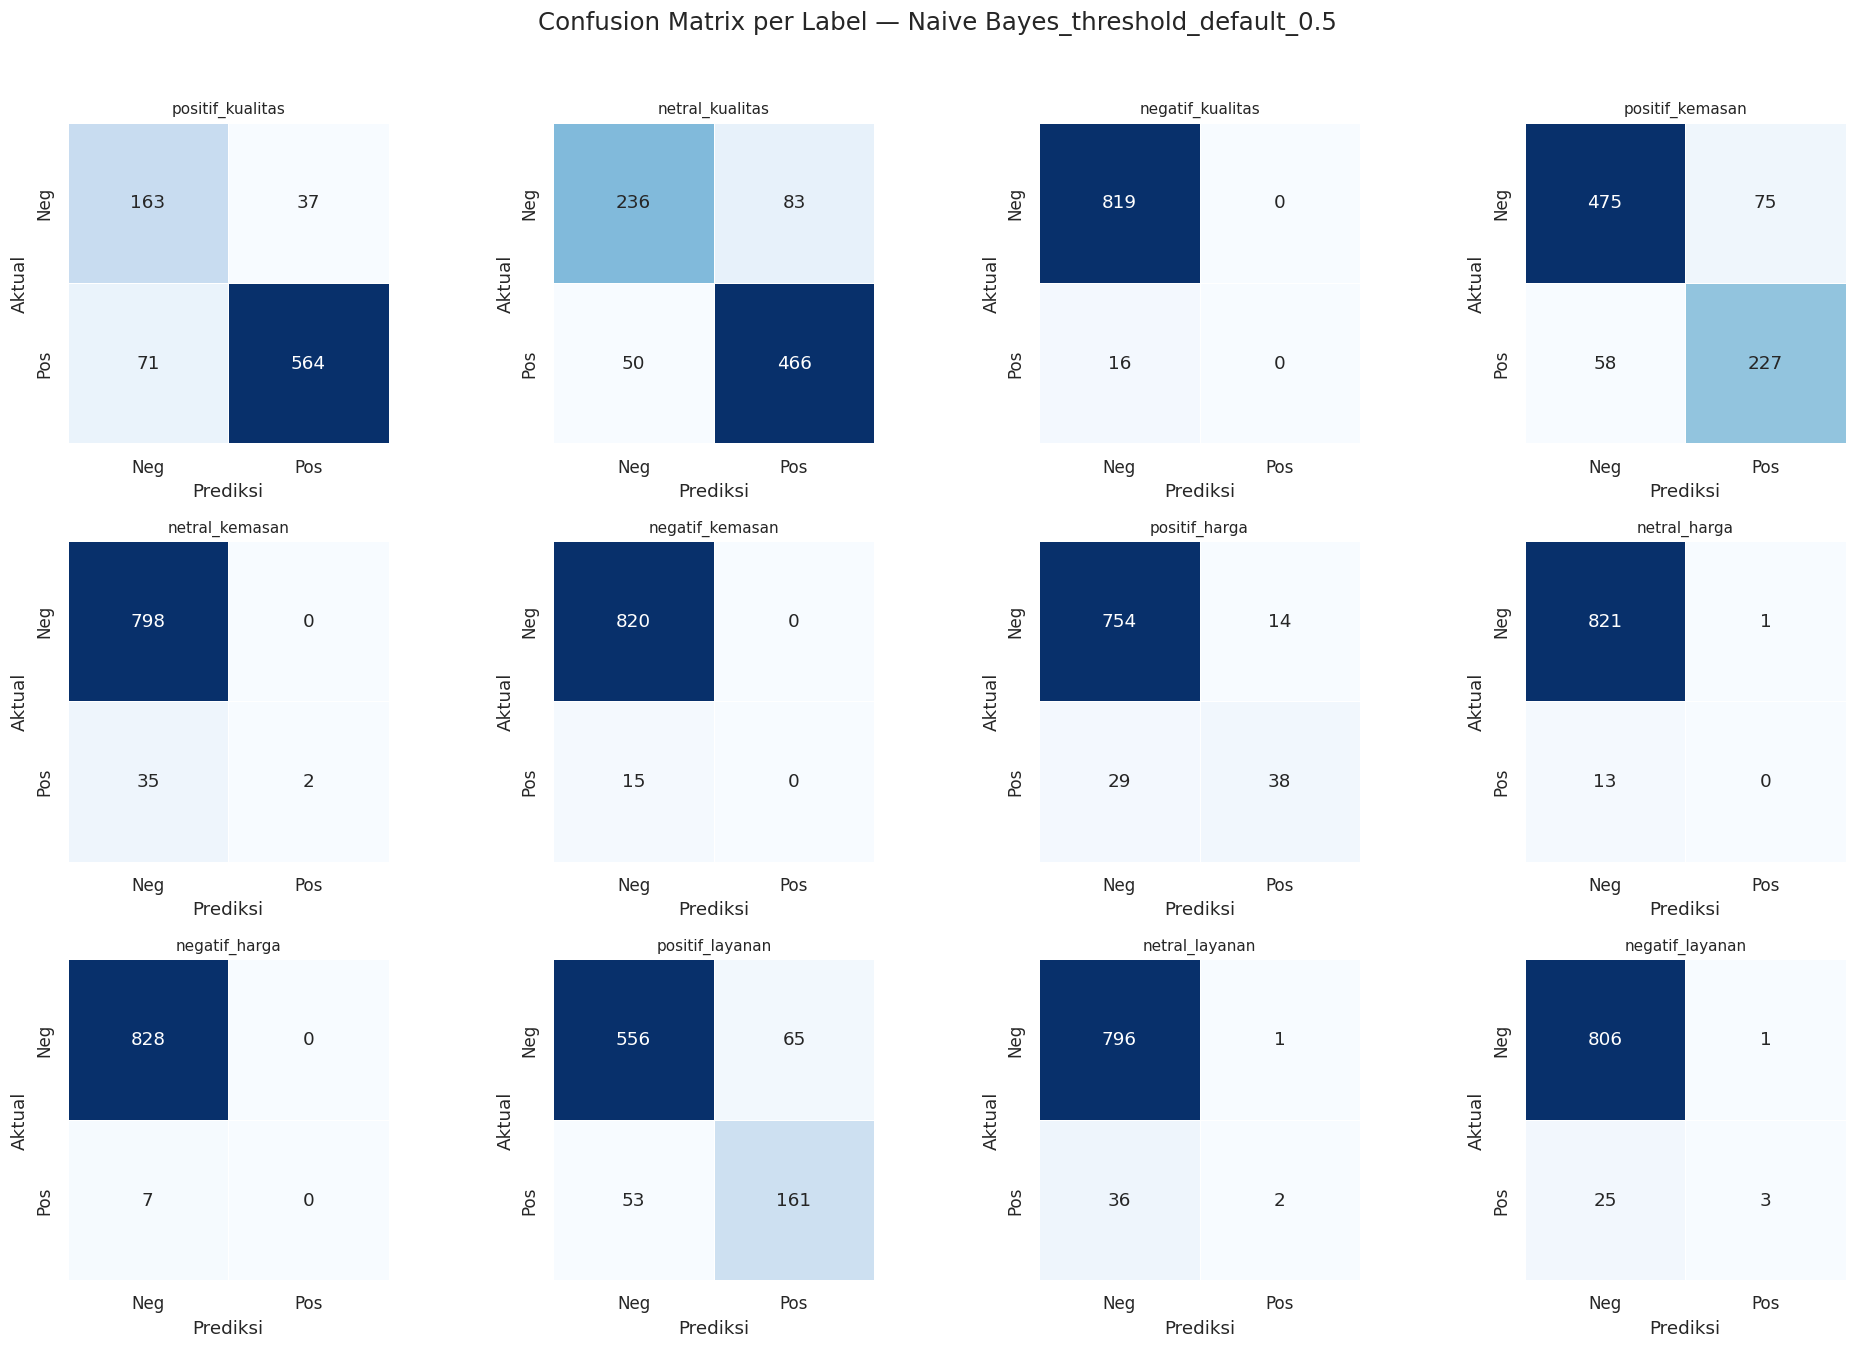


===== Naive Bayes_threshold_default_0.5 =====
                  precision    recall  f1-score   support

positif_kualitas       0.94      0.89      0.91       635
 netral_kualitas       0.85      0.90      0.88       516
negatif_kualitas       0.00      0.00      0.00        16
 positif_kemasan       0.75      0.80      0.77       285
  netral_kemasan       1.00      0.05      0.10        37
 negatif_kemasan       0.00      0.00      0.00        15
   positif_harga       0.73      0.57      0.64        67
    netral_harga       0.00      0.00      0.00        13
   negatif_harga       0.00      0.00      0.00         7
 positif_layanan       0.71      0.75      0.73       214
  netral_layanan       0.67      0.05      0.10        38
 negatif_layanan       0.75      0.11      0.19        28

       micro avg       0.84      0.78      0.81      1871
       macro avg       0.53      0.34      0.36      1871
    weighted avg       0.82      0.78      0.78      1871
     samples avg       

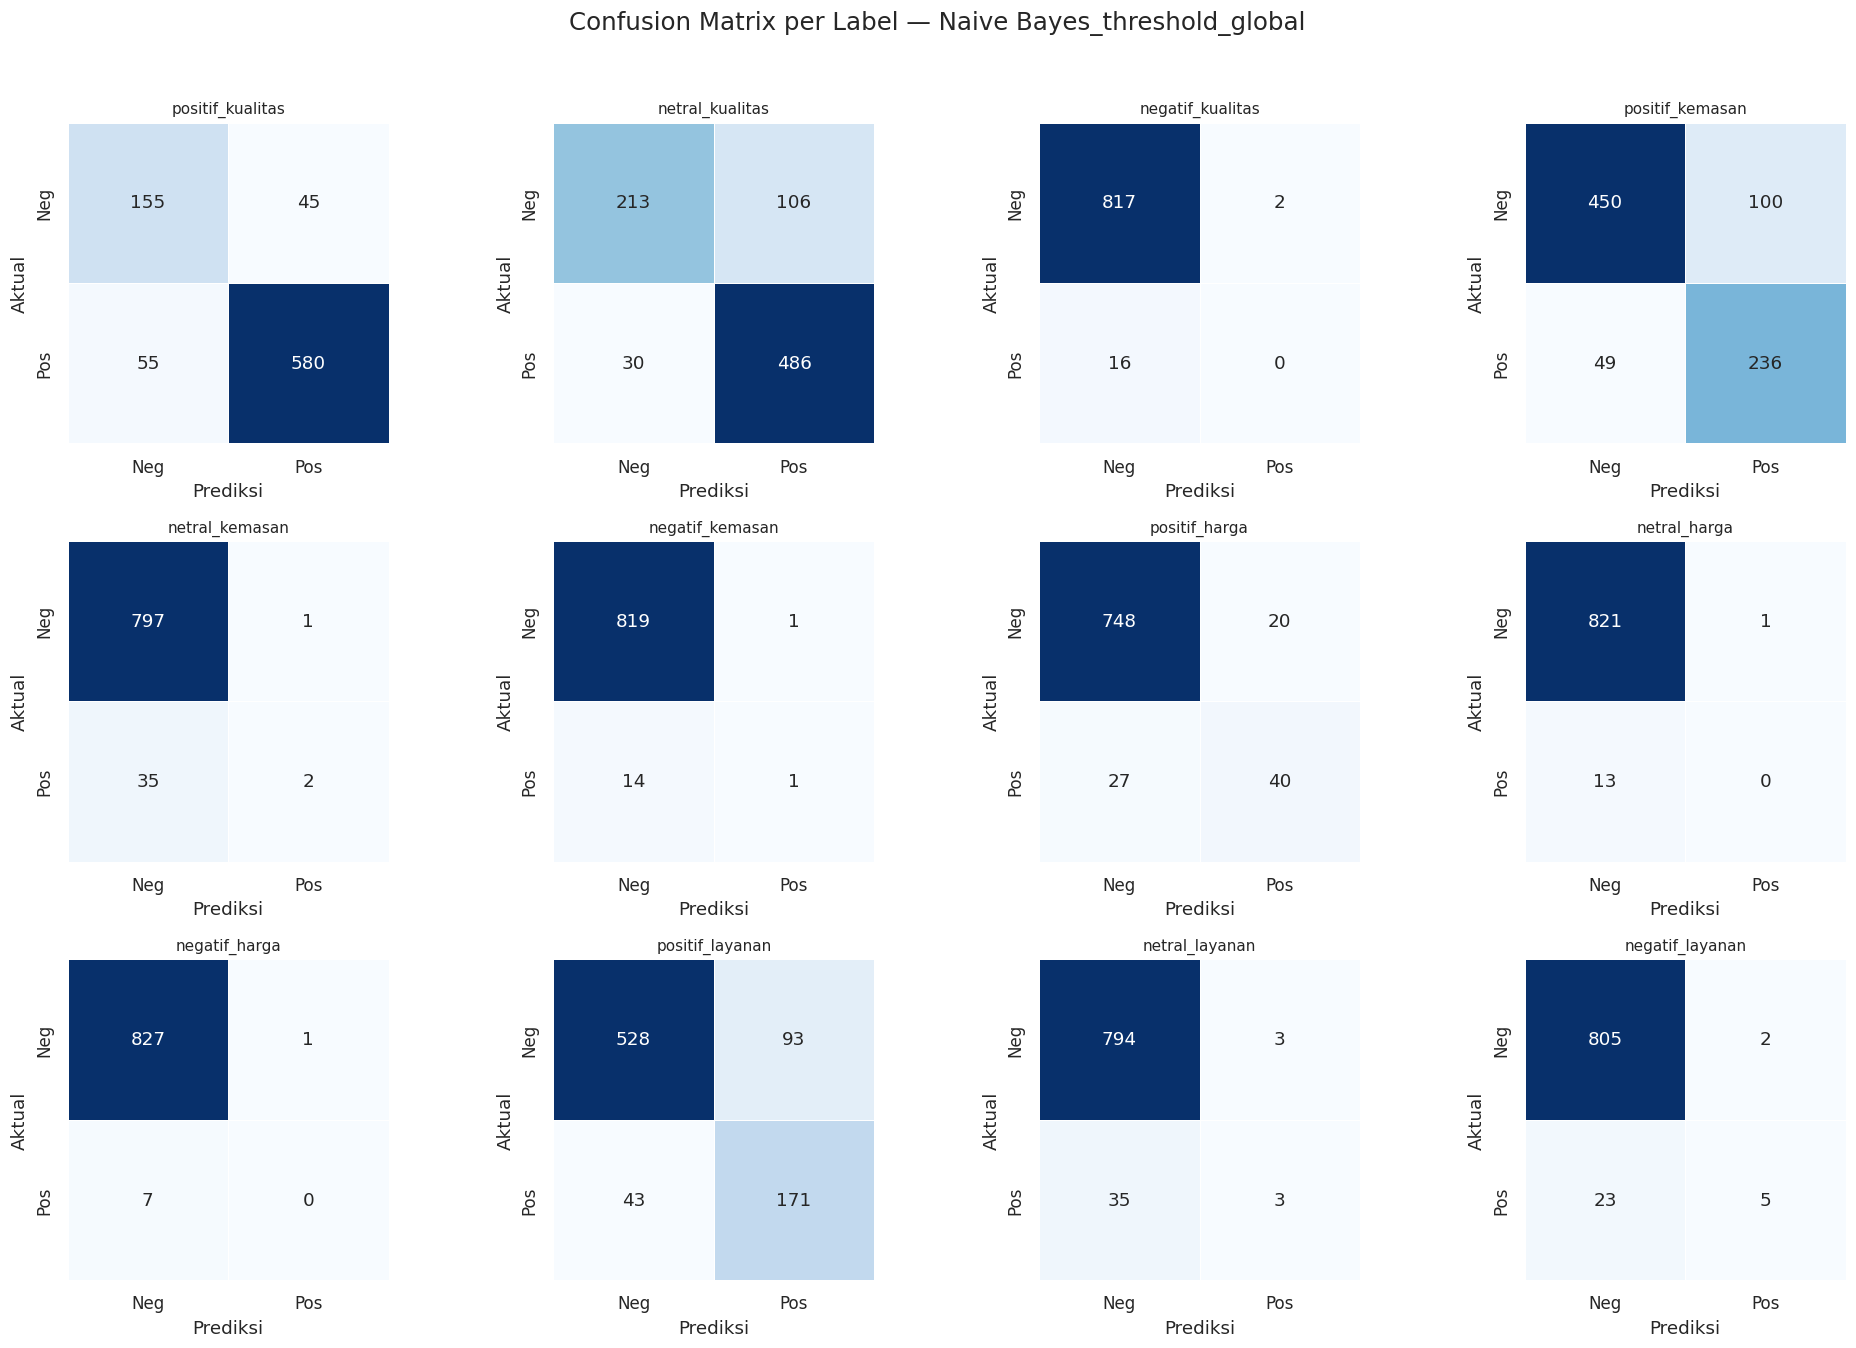


===== Naive Bayes_threshold_global =====
                  precision    recall  f1-score   support

positif_kualitas       0.93      0.91      0.92       635
 netral_kualitas       0.82      0.94      0.88       516
negatif_kualitas       0.00      0.00      0.00        16
 positif_kemasan       0.70      0.83      0.76       285
  netral_kemasan       0.67      0.05      0.10        37
 negatif_kemasan       0.50      0.07      0.12        15
   positif_harga       0.67      0.60      0.63        67
    netral_harga       0.00      0.00      0.00        13
   negatif_harga       0.00      0.00      0.00         7
 positif_layanan       0.65      0.80      0.72       214
  netral_layanan       0.50      0.08      0.14        38
 negatif_layanan       0.71      0.18      0.29        28

       micro avg       0.80      0.81      0.81      1871
       macro avg       0.51      0.37      0.38      1871
    weighted avg       0.78      0.81      0.78      1871
     samples avg       0.83 

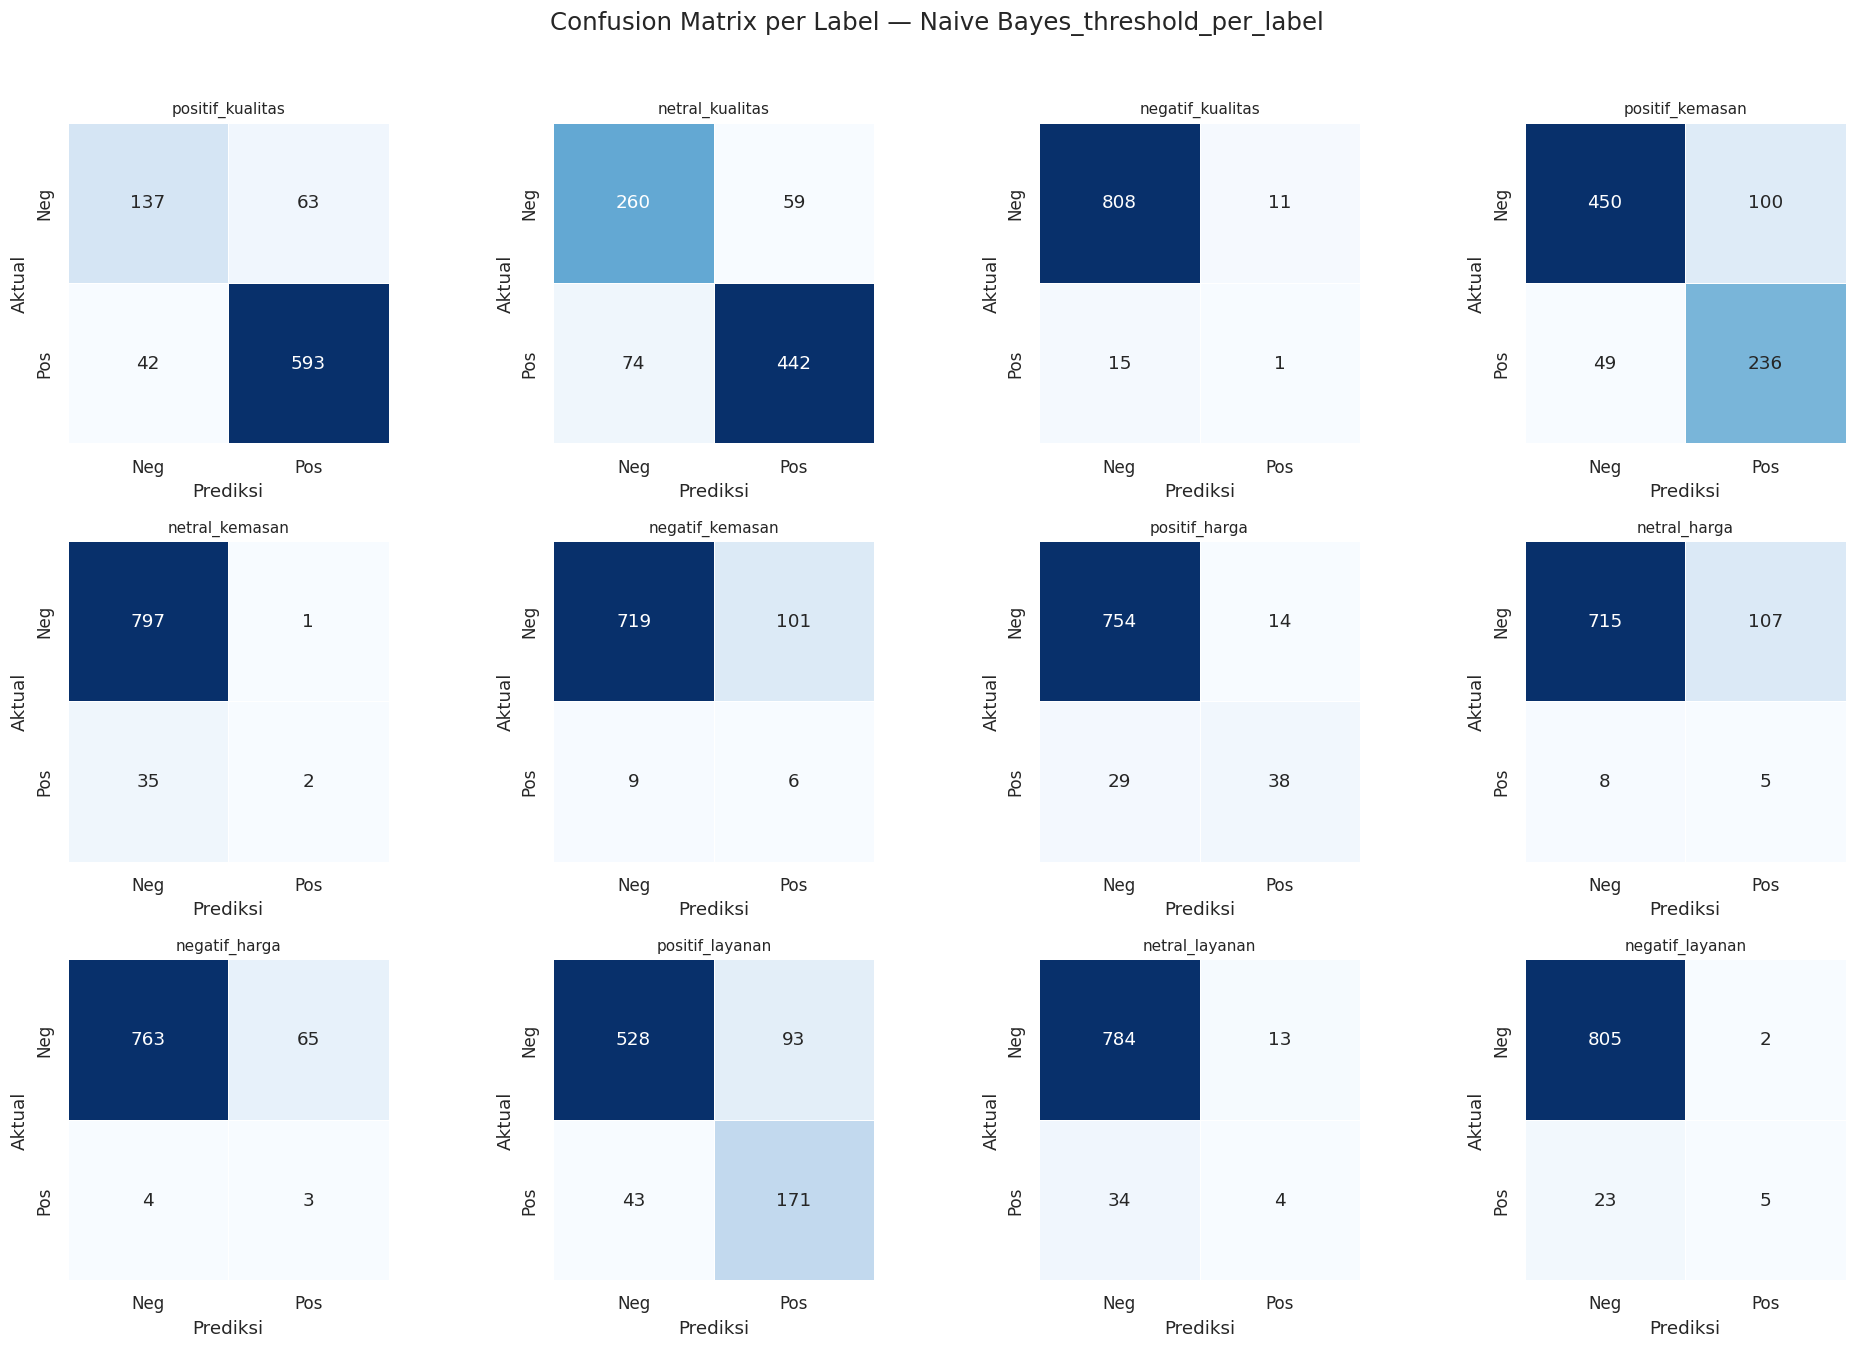


===== Naive Bayes_threshold_per_label =====
                  precision    recall  f1-score   support

positif_kualitas       0.90      0.93      0.92       635
 netral_kualitas       0.88      0.86      0.87       516
negatif_kualitas       0.08      0.06      0.07        16
 positif_kemasan       0.70      0.83      0.76       285
  netral_kemasan       0.67      0.05      0.10        37
 negatif_kemasan       0.06      0.40      0.10        15
   positif_harga       0.73      0.57      0.64        67
    netral_harga       0.04      0.38      0.08        13
   negatif_harga       0.04      0.43      0.08         7
 positif_layanan       0.65      0.80      0.72       214
  netral_layanan       0.24      0.11      0.15        38
 negatif_layanan       0.71      0.18      0.29        28

       micro avg       0.71      0.80      0.75      1871
       macro avg       0.48      0.47      0.40      1871
    weighted avg       0.79      0.80      0.78      1871
     samples avg       0.

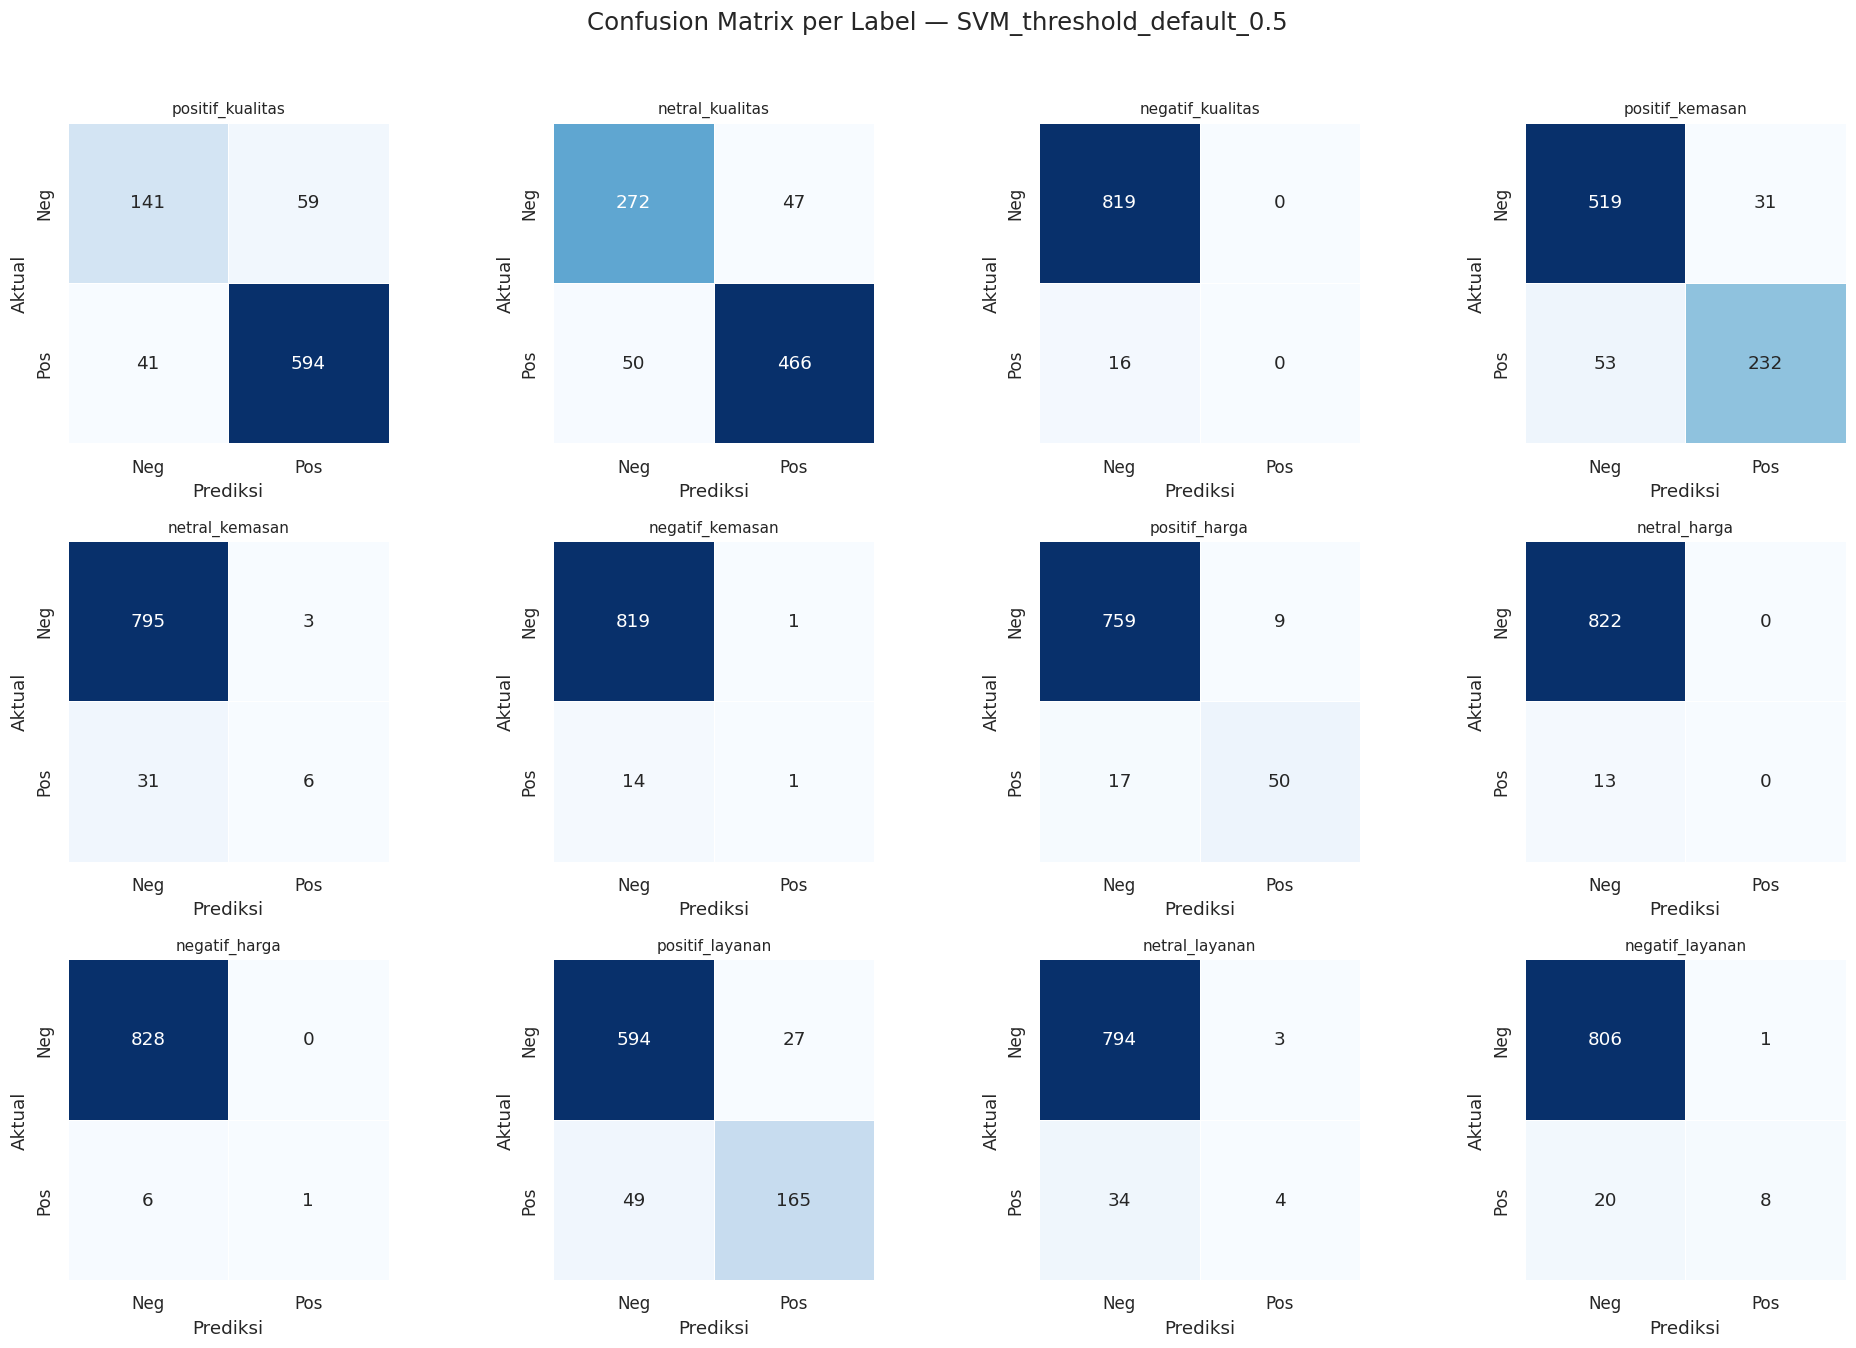


===== SVM_threshold_default_0.5 =====
                  precision    recall  f1-score   support

positif_kualitas       0.91      0.94      0.92       635
 netral_kualitas       0.91      0.90      0.91       516
negatif_kualitas       0.00      0.00      0.00        16
 positif_kemasan       0.88      0.81      0.85       285
  netral_kemasan       0.67      0.16      0.26        37
 negatif_kemasan       0.50      0.07      0.12        15
   positif_harga       0.85      0.75      0.79        67
    netral_harga       0.00      0.00      0.00        13
   negatif_harga       1.00      0.14      0.25         7
 positif_layanan       0.86      0.77      0.81       214
  netral_layanan       0.57      0.11      0.18        38
 negatif_layanan       0.89      0.29      0.43        28

       micro avg       0.89      0.82      0.85      1871
       macro avg       0.67      0.41      0.46      1871
    weighted avg       0.87      0.82      0.83      1871
     samples avg       0.90    

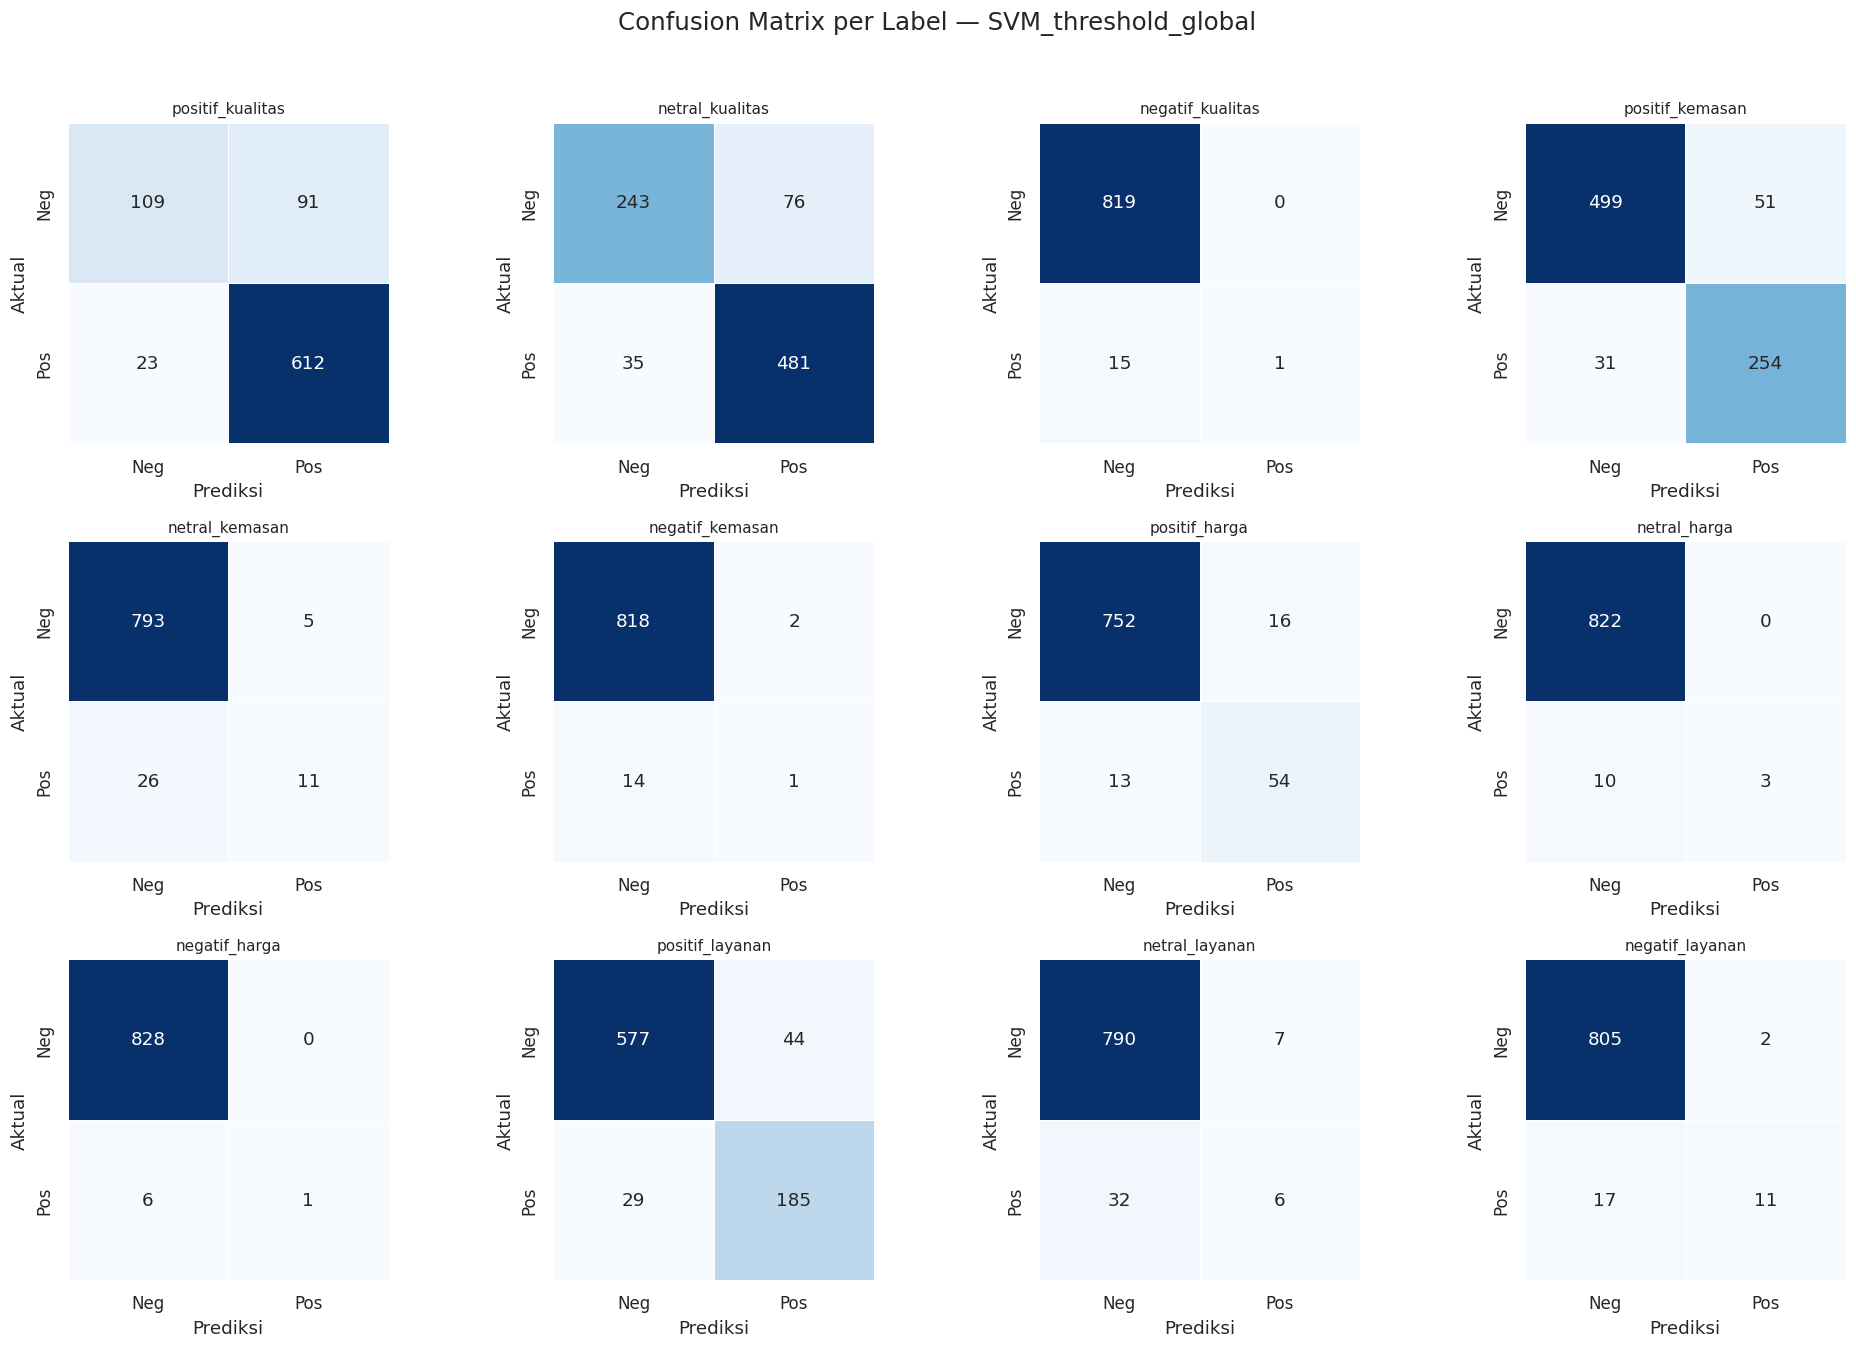


===== SVM_threshold_global =====
                  precision    recall  f1-score   support

positif_kualitas       0.87      0.96      0.91       635
 netral_kualitas       0.86      0.93      0.90       516
negatif_kualitas       1.00      0.06      0.12        16
 positif_kemasan       0.83      0.89      0.86       285
  netral_kemasan       0.69      0.30      0.42        37
 negatif_kemasan       0.33      0.07      0.11        15
   positif_harga       0.77      0.81      0.79        67
    netral_harga       1.00      0.23      0.38        13
   negatif_harga       1.00      0.14      0.25         7
 positif_layanan       0.81      0.86      0.84       214
  netral_layanan       0.46      0.16      0.24        38
 negatif_layanan       0.85      0.39      0.54        28

       micro avg       0.85      0.87      0.86      1871
       macro avg       0.79      0.48      0.53      1871
    weighted avg       0.84      0.87      0.84      1871
     samples avg       0.86      0.8

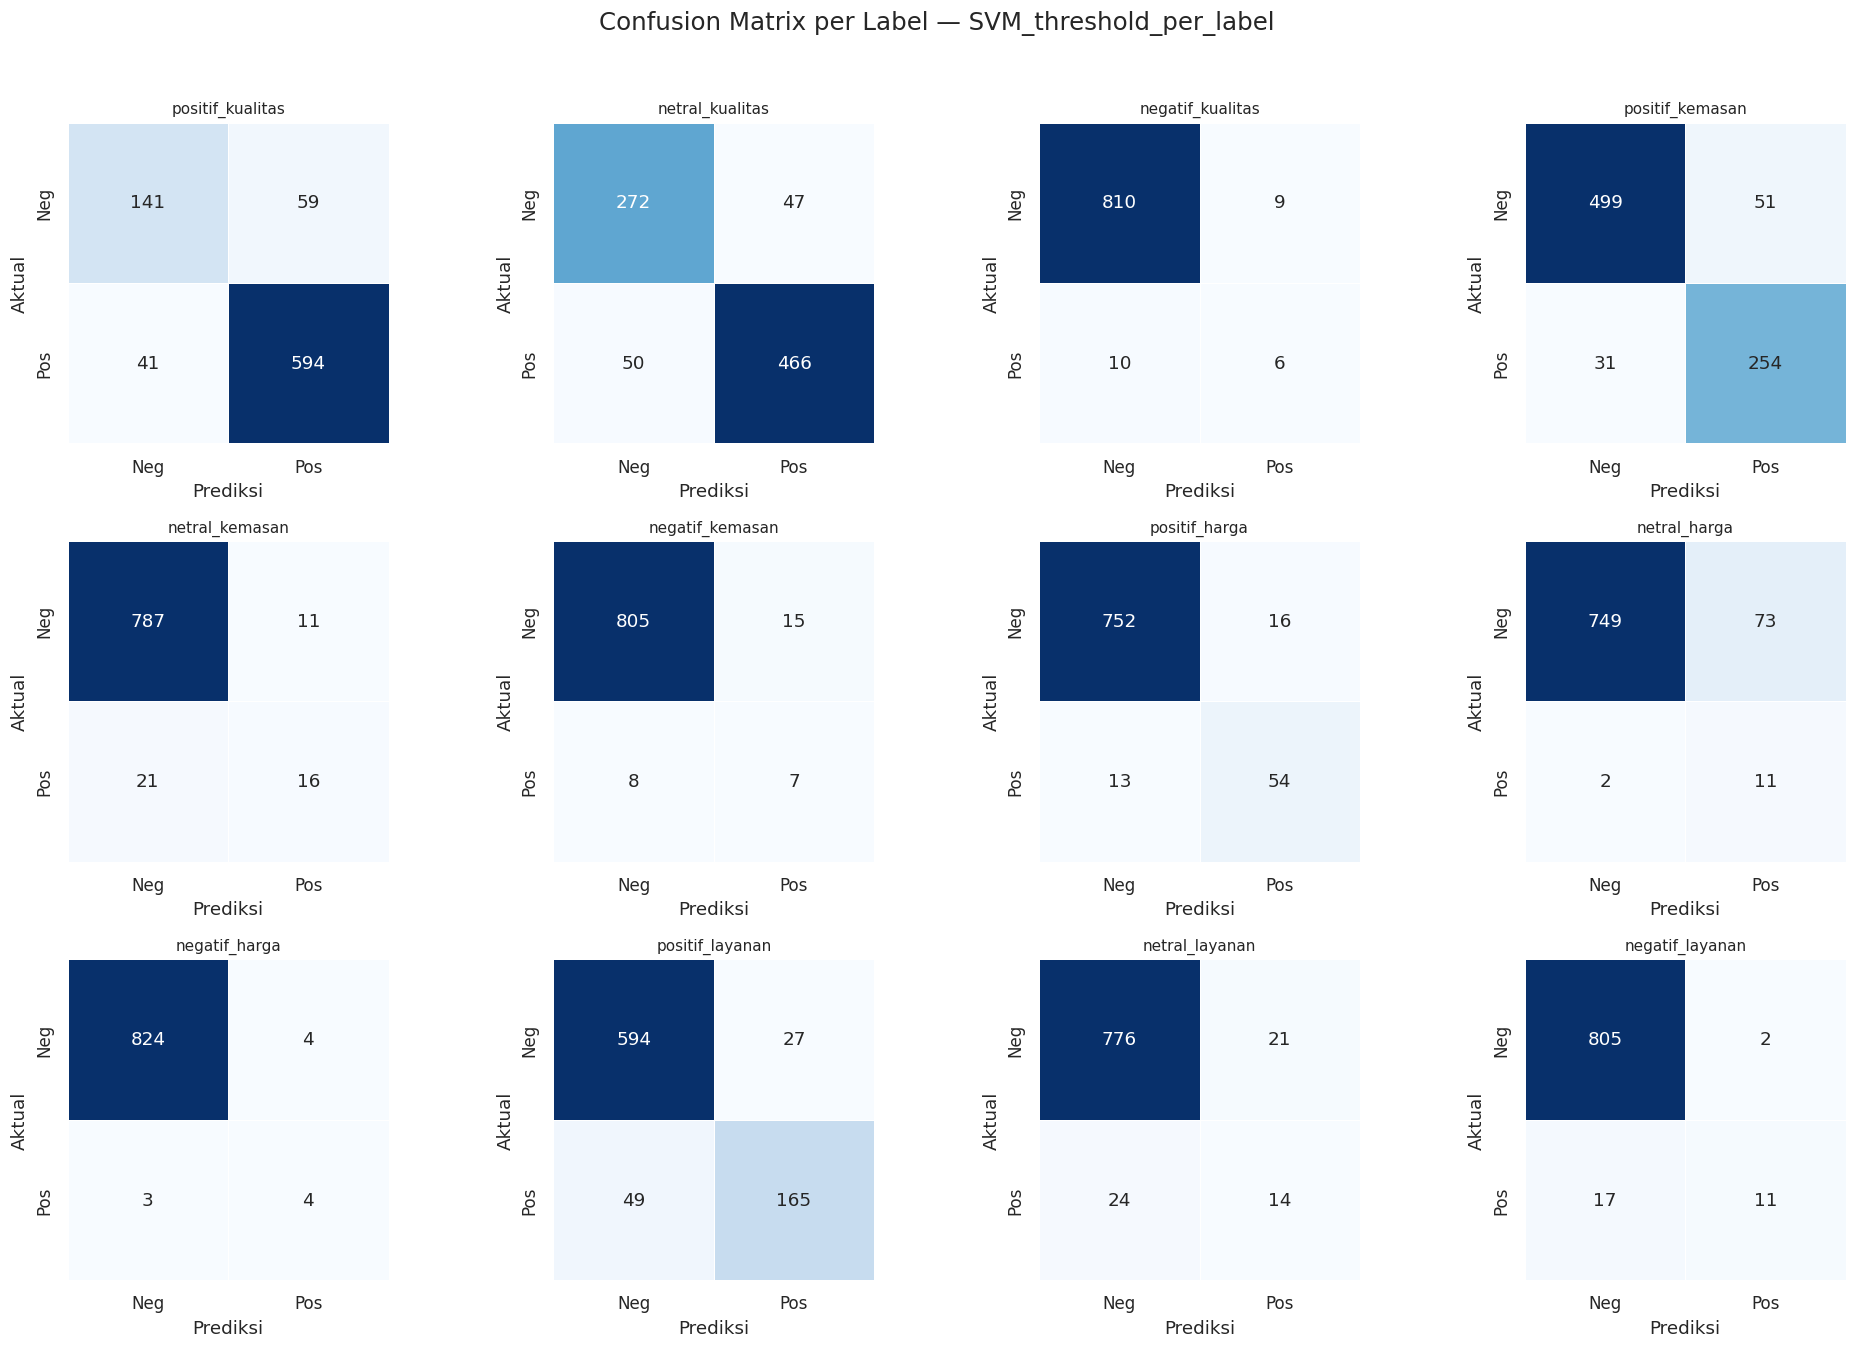


===== SVM_threshold_per_label =====
                  precision    recall  f1-score   support

positif_kualitas       0.91      0.94      0.92       635
 netral_kualitas       0.91      0.90      0.91       516
negatif_kualitas       0.40      0.38      0.39        16
 positif_kemasan       0.83      0.89      0.86       285
  netral_kemasan       0.59      0.43      0.50        37
 negatif_kemasan       0.32      0.47      0.38        15
   positif_harga       0.77      0.81      0.79        67
    netral_harga       0.13      0.85      0.23        13
   negatif_harga       0.50      0.57      0.53         7
 positif_layanan       0.86      0.77      0.81       214
  netral_layanan       0.40      0.37      0.38        38
 negatif_layanan       0.85      0.39      0.54        28

       micro avg       0.83      0.86      0.84      1871
       macro avg       0.62      0.65      0.60      1871
    weighted avg       0.85      0.86      0.85      1871
     samples avg       0.85      

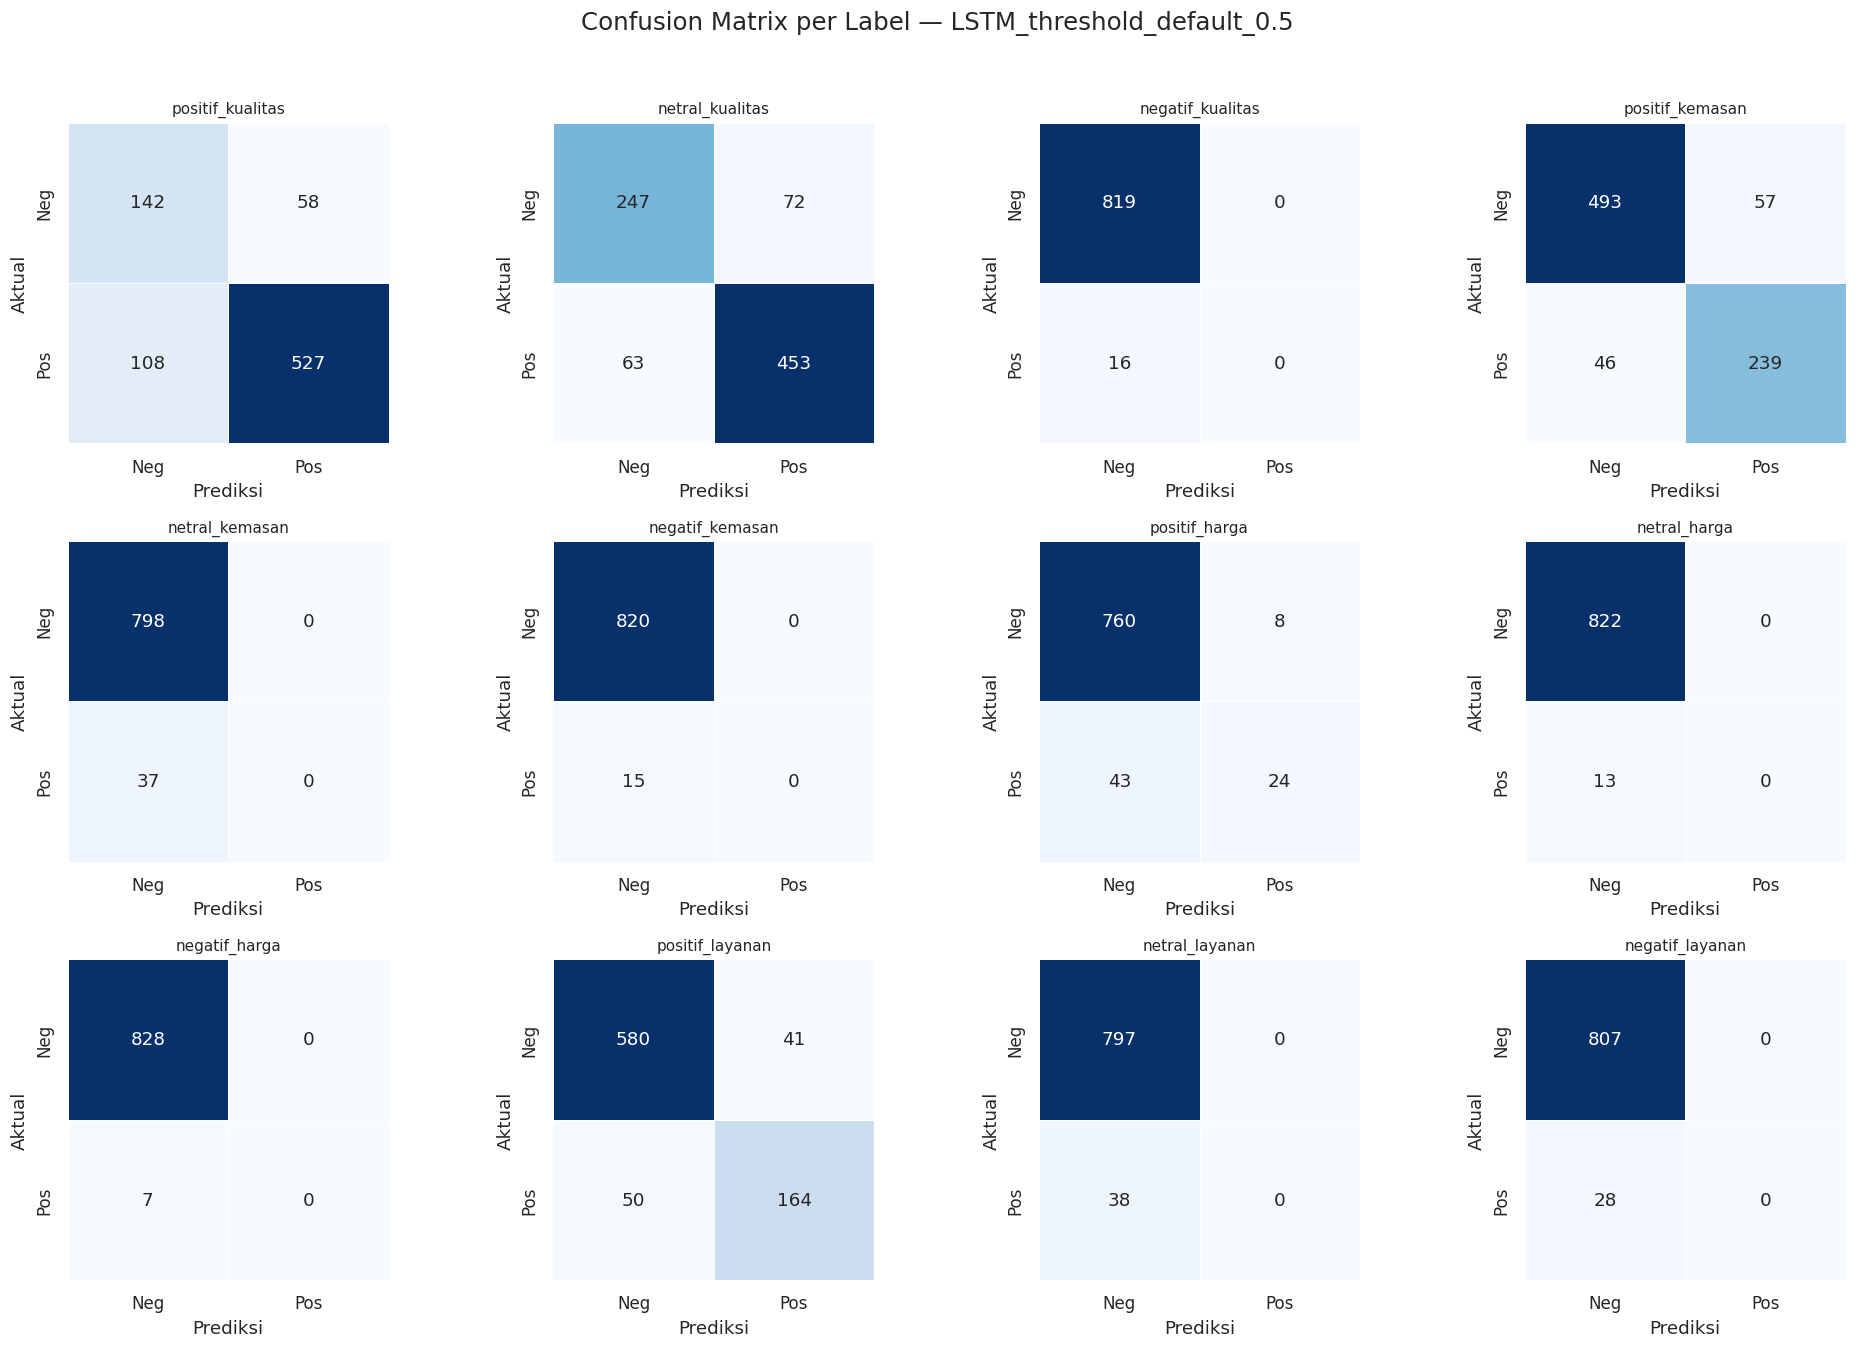


===== LSTM_threshold_default_0.5 =====
                  precision    recall  f1-score   support

positif_kualitas       0.90      0.83      0.86       635
 netral_kualitas       0.86      0.88      0.87       516
negatif_kualitas       0.00      0.00      0.00        16
 positif_kemasan       0.81      0.84      0.82       285
  netral_kemasan       0.00      0.00      0.00        37
 negatif_kemasan       0.00      0.00      0.00        15
   positif_harga       0.75      0.36      0.48        67
    netral_harga       0.00      0.00      0.00        13
   negatif_harga       0.00      0.00      0.00         7
 positif_layanan       0.80      0.77      0.78       214
  netral_layanan       0.00      0.00      0.00        38
 negatif_layanan       0.00      0.00      0.00        28

       micro avg       0.86      0.75      0.80      1871
       macro avg       0.34      0.31      0.32      1871
    weighted avg       0.79      0.75      0.77      1871
     samples avg       0.86   

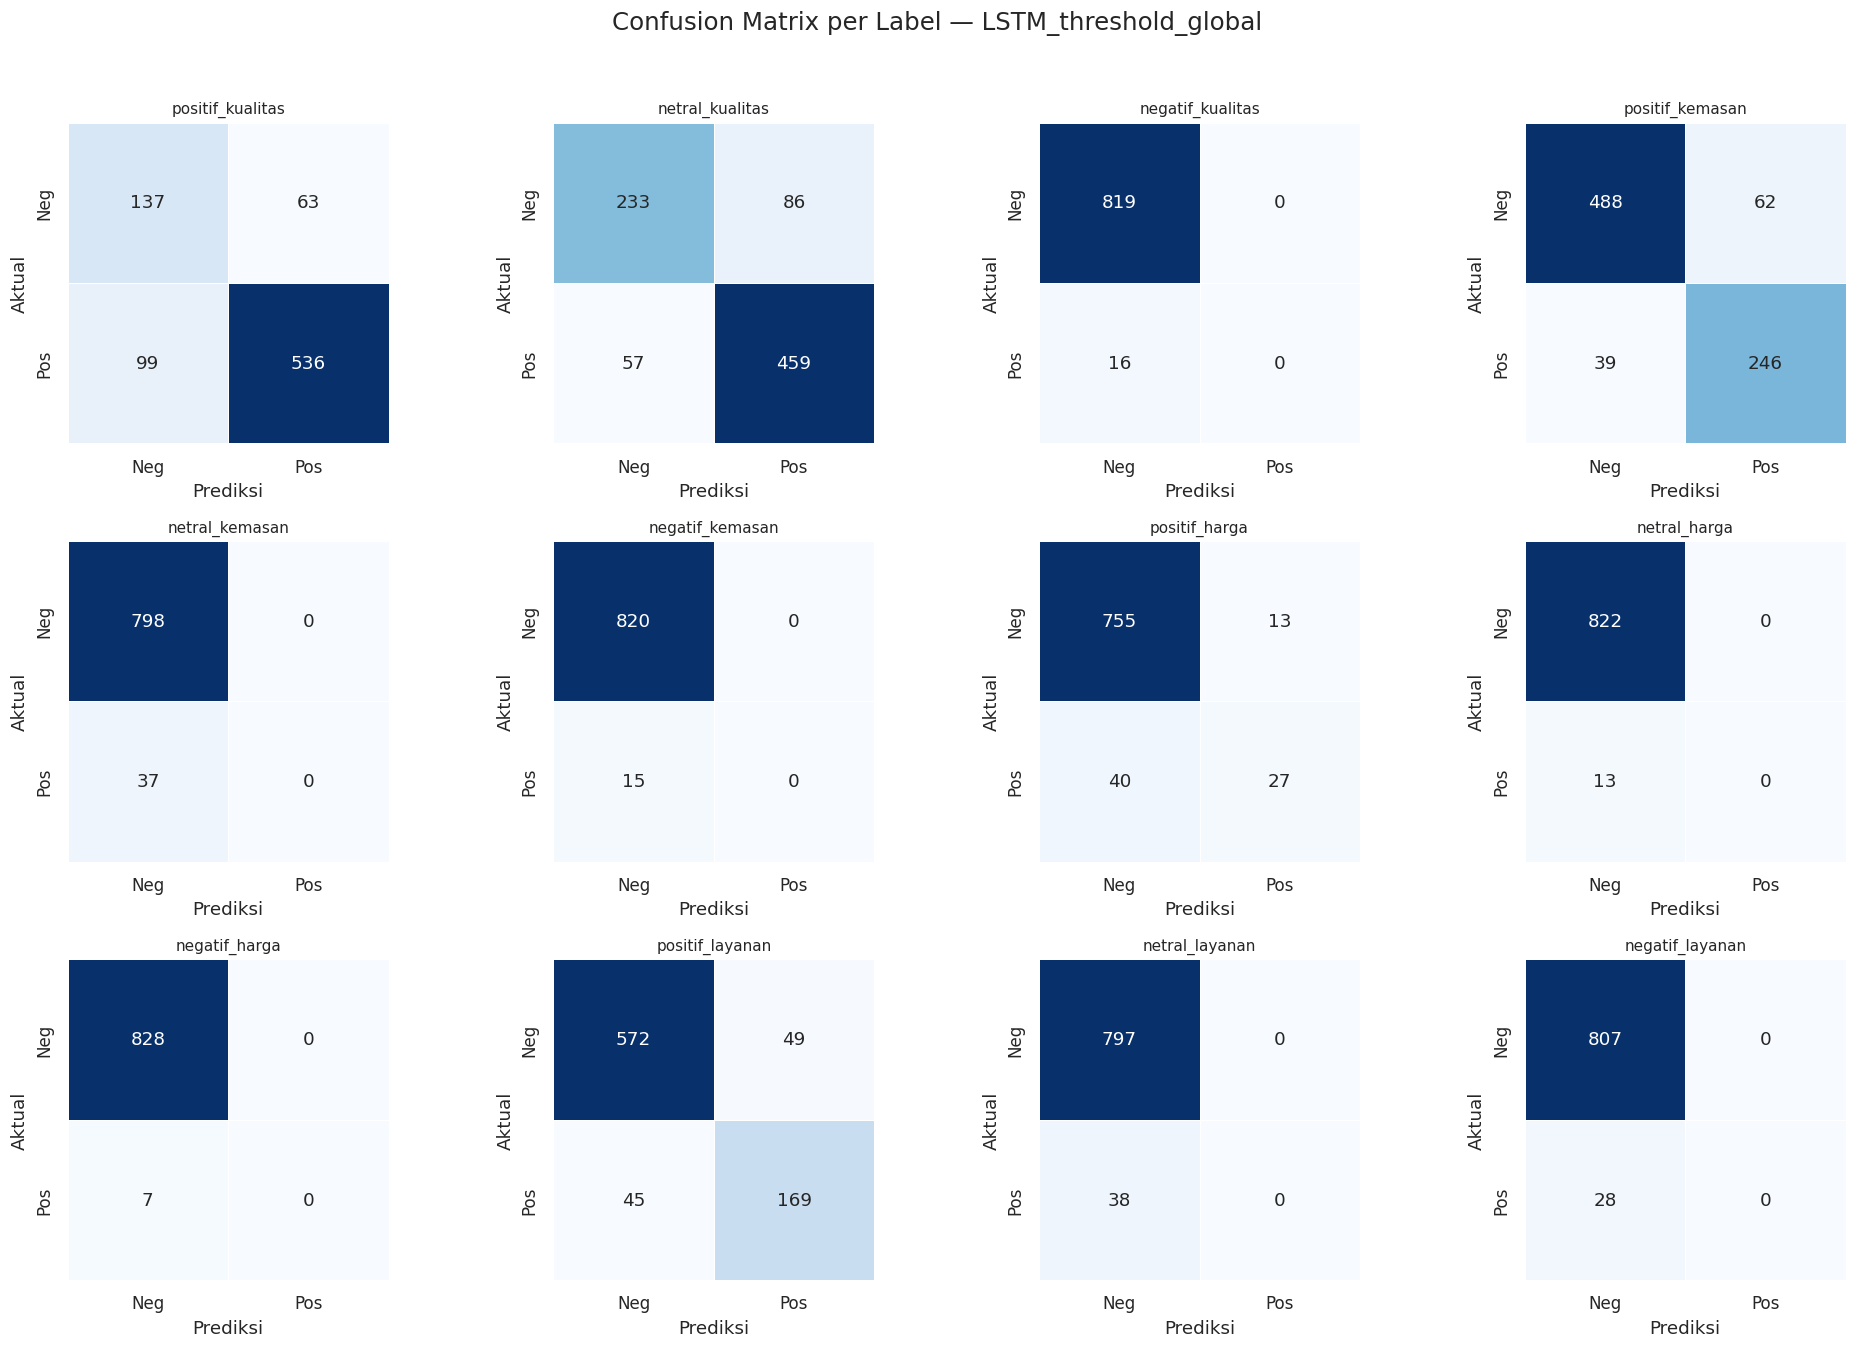


===== LSTM_threshold_global =====
                  precision    recall  f1-score   support

positif_kualitas       0.89      0.84      0.87       635
 netral_kualitas       0.84      0.89      0.87       516
negatif_kualitas       0.00      0.00      0.00        16
 positif_kemasan       0.80      0.86      0.83       285
  netral_kemasan       0.00      0.00      0.00        37
 negatif_kemasan       0.00      0.00      0.00        15
   positif_harga       0.68      0.40      0.50        67
    netral_harga       0.00      0.00      0.00        13
   negatif_harga       0.00      0.00      0.00         7
 positif_layanan       0.78      0.79      0.78       214
  netral_layanan       0.00      0.00      0.00        38
 negatif_layanan       0.00      0.00      0.00        28

       micro avg       0.84      0.77      0.80      1871
       macro avg       0.33      0.32      0.32      1871
    weighted avg       0.77      0.77      0.77      1871
     samples avg       0.85      0.

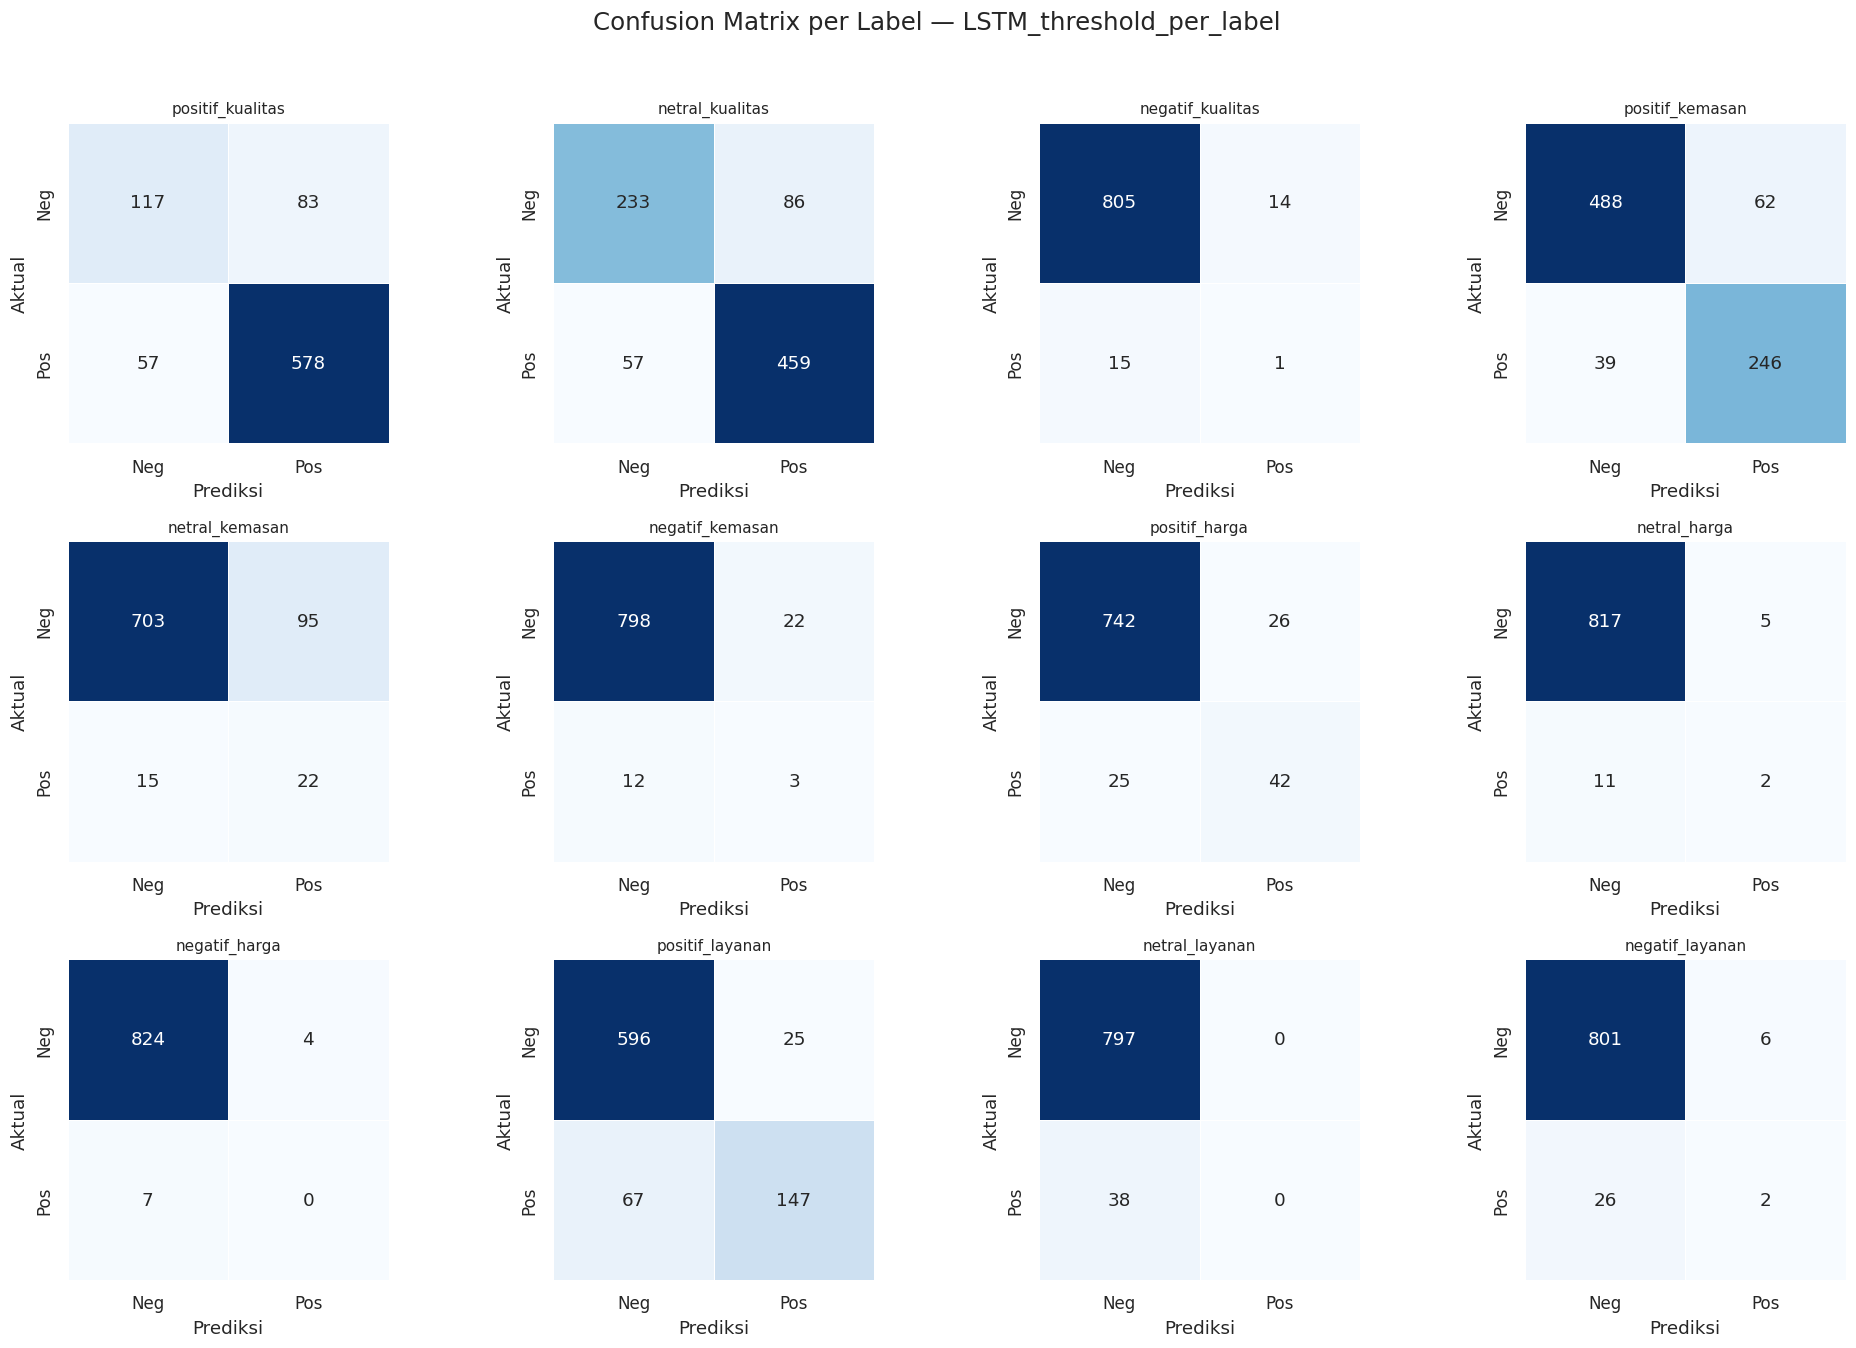


===== LSTM_threshold_per_label =====
                  precision    recall  f1-score   support

positif_kualitas       0.87      0.91      0.89       635
 netral_kualitas       0.84      0.89      0.87       516
negatif_kualitas       0.07      0.06      0.06        16
 positif_kemasan       0.80      0.86      0.83       285
  netral_kemasan       0.19      0.59      0.29        37
 negatif_kemasan       0.12      0.20      0.15        15
   positif_harga       0.62      0.63      0.62        67
    netral_harga       0.29      0.15      0.20        13
   negatif_harga       0.00      0.00      0.00         7
 positif_layanan       0.85      0.69      0.76       214
  netral_layanan       0.00      0.00      0.00        38
 negatif_layanan       0.25      0.07      0.11        28

       micro avg       0.78      0.80      0.79      1871
       macro avg       0.41      0.42      0.40      1871
    weighted avg       0.78      0.80      0.79      1871
     samples avg       0.82     

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix

for name, (Y_true, pred) in final_preds.items():

    mcm = multilabel_confusion_matrix(Y_true, pred)

    fig, axes = plt.subplots(3,4, figsize=(18,12))

    for ax, cm, label in zip(axes.ravel(), mcm, classes):

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            square=True,
            linewidths=0.5,
            ax=ax,
            xticklabels=['Neg','Pos'],
            yticklabels=['Neg','Pos']
        )

        ax.set_title(label, fontsize=10)
        ax.set_xlabel("Prediksi")
        ax.set_ylabel("Aktual")

    plt.suptitle(
        f"Confusion Matrix per Label — {name}",
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()
    plt.show()

    print(f"\n===== {name} =====")
    print(classification_report(
        Y_true,
        pred,
        target_names=classes,
        zero_division=0
    ))

In [ ]:
# ============================================================
# CELL 11
# THRESHOLD FINAL SVM BASELINE PER LABEL DARI 5 FOLD
# ============================================================

import numpy as np
import pandas as pd

# ============================================================
# AMBIL HASIL THRESHOLD SVM BASELINE
# ============================================================

df_thr_svm_baseline = df_thr_baseline[
    (df_thr_baseline['model'] == 'SVM') &
    (df_thr_baseline['scenario'] == 'murni')
].copy()

print("Jumlah fold SVM baseline:", len(df_thr_svm_baseline))

# Pastikan benar-benar 5 fold
if len(df_thr_svm_baseline) != 5:
    raise ValueError(
        f"Threshold SVM baseline seharusnya berasal dari 5 fold, "
        f"tetapi ditemukan {len(df_thr_svm_baseline)}."
    )

# ============================================================
# AMBIL THRESHOLD PER LABEL
# ============================================================

threshold_matrix_baseline = np.array(
    df_thr_svm_baseline['threshold_per_label'].tolist(),
    dtype=float
)

print(
    "Shape threshold matrix:",
    threshold_matrix_baseline.shape
)

# ============================================================
# THRESHOLD FINAL
# ============================================================

threshold_per_label_final_baseline = threshold_matrix_baseline.mean(axis=0)

# Batasi agar tetap berada pada rentang 0.1 - 0.9
threshold_per_label_final_baseline = np.clip(
    threshold_per_label_final_baseline,
    0.1,
    0.9
)

print("\n==============================================")
print("THRESHOLD FINAL SVM BASELINE PER LABEL")
print("==============================================")

for label, threshold in zip(
    classes,
    threshold_per_label_final_baseline
):
    print(
        f"{label:25s} : {threshold:.4f}"
    )

# ============================================================
# CEK KHUSUS LABEL NEGATIF
# ============================================================

print("\n==============================================")
print("THRESHOLD LABEL NEGATIF")
print("==============================================")

for label, threshold in zip(
    classes,
    threshold_per_label_final_baseline
):
    if label.startswith("negatif_"):
        print(
            f"{label:25s} : {threshold:.4f}"
        )

Jumlah fold SVM baseline: 5
Shape threshold matrix: (5, 12)

THRESHOLD FINAL SVM BASELINE PER LABEL
positif_kualitas          : 0.4600
netral_kualitas           : 0.5000
negatif_kualitas          : 0.3600
positif_kemasan           : 0.4600
netral_kemasan            : 0.3800
negatif_kemasan           : 0.4000
positif_harga             : 0.4400
netral_harga              : 0.3600
negatif_harga             : 0.3500
positif_layanan           : 0.4600
netral_layanan            : 0.3800
negatif_layanan           : 0.4300

THRESHOLD LABEL NEGATIF
negatif_kualitas          : 0.3600
negatif_kemasan           : 0.4000
negatif_harga             : 0.3500
negatif_layanan           : 0.4300


In [ ]:
# ============================================================
# CELL 12
# TRAIN FINAL SVM BASELINE UNTUK DEPLOYMENT
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC

# ============================================================
# 1. TF-IDF FINAL
# ============================================================

tfidf_final_baseline = TfidfVectorizer(
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)

# Fit TF-IDF menggunakan SELURUH DATA
X_full_baseline = tfidf_final_baseline.fit_transform(texts)

print(
    "Shape TF-IDF:",
    X_full_baseline.shape
)

# ============================================================
# 2. TRAIN SVM FINAL
# ============================================================

svm_final_baseline = OneVsRestClassifier(
    LinearSVC(
        C=1.0,
        max_iter=5000,
        random_state=42
    )
)

svm_final_baseline.fit(
    X_full_baseline,
    Y
)

print("SVM baseline final berhasil dilatih.")

# ============================================================
# 3. CEK JUMLAH LABEL
# ============================================================

print(
    "Jumlah label model:",
    len(svm_final_baseline.estimators_)
)

print(
    "Jumlah classes:",
    len(classes)
)

Shape TF-IDF: (4226, 10915)
SVM baseline final berhasil dilatih.
Jumlah label model: 12
Jumlah classes: 12


In [ ]:
# ============================================================
# CELL 13
# SIMPAN FILE DEPLOYMENT SVM BASELINE
# ============================================================

import joblib
import pickle
import json
import os

# ============================================================
# 1. SIMPAN TF-IDF FINAL
# ============================================================

joblib.dump(
    tfidf_final_baseline,
    'preprocessor_tfidf_baseline.pkl'
)

print("✓ preprocessor_tfidf_baseline.pkl")


# ============================================================
# 2. SIMPAN SVM FINAL
# ============================================================

joblib.dump(
    svm_final_baseline,
    'svm_model_baseline.pkl'
)

print("✓ svm_model_baseline.pkl")


# ============================================================
# 3. SIMPAN THRESHOLD FINAL
# ============================================================

joblib.dump(
    threshold_per_label_final_baseline,
    'threshold_per_label_baseline.pkl'
)

print("✓ threshold_per_label_baseline.pkl")


# ============================================================
# 4. SIMPAN CLASSES
# ============================================================

with open(
    'classes_baseline.pkl',
    'wb'
) as f:

    pickle.dump(
        classes,
        f
    )

print("✓ classes_baseline.pkl")


# ============================================================
# 5. SIMPAN HASIL EVALUASI
# ============================================================

best_result_baseline = ringkasan_murni.loc[
    ('SVM', 'threshold_per_label')
]

results_baseline = {}

for key, value in best_result_baseline.items():

    if isinstance(key, tuple):
        key = '_'.join(str(x) for x in key)

    if pd.notna(value):
        results_baseline[str(key)] = float(value)


# Tambahkan threshold yang digunakan
results_baseline["threshold_per_label"] = {
    str(label): float(threshold)
    for label, threshold in zip(
        classes,
        threshold_per_label_final_baseline
    )
}


with open(
    'svm_results_baseline.json',
    'w'
) as f:

    json.dump(
        results_baseline,
        f,
        indent=4
    )

print("✓ svm_results_baseline.json")


# ============================================================
# 6. SIMPAN RINGKASAN MODEL
# ============================================================

ringkasan_murni.to_csv(
    'model_summary_baseline.csv',
    index=True
)

print("✓ model_summary_baseline.csv")


# ============================================================
# 7. CEK FILE
# ============================================================

print("\n==============================================")
print("FILE DEPLOYMENT SVM BASELINE")
print("==============================================")

files_baseline = [
    'preprocessor_tfidf_baseline.pkl',
    'svm_model_baseline.pkl',
    'threshold_per_label_baseline.pkl',
    'classes_baseline.pkl',
    'svm_results_baseline.json',
    'model_summary_baseline.csv'
]

for file in files_baseline:

    if os.path.exists(file):

        size = os.path.getsize(file) / 1024

        print(
            f"✓ {file} ({size:.1f} KB)"
        )

    else:

        print(
            f"✗ {file} TIDAK DITEMUKAN"
        )

✓ preprocessor_tfidf_baseline.pkl
✓ svm_model_baseline.pkl
✓ threshold_per_label_baseline.pkl
✓ classes_baseline.pkl
✓ svm_results_baseline.json
✓ model_summary_baseline.csv

FILE DEPLOYMENT SVM BASELINE
✓ preprocessor_tfidf_baseline.pkl (260.6 KB)
✓ svm_model_baseline.pkl (1027.7 KB)
✓ threshold_per_label_baseline.pkl (0.3 KB)
✓ classes_baseline.pkl (0.2 KB)
✓ svm_results_baseline.json (1.0 KB)
✓ model_summary_baseline.csv (1.2 KB)
